**TRC3500 Project 3 - Breath Cycle Estimation**

Connecting to COM10...
System Active. Recording for 30 seconds...

Time: 4.1s | Gate: OFF | Band: 3.29V | Total: 0
[VALIDATED BREATH] Count: 1
Time: 6.4s | Gate: ON  | Band: 1.78V | Total: 1
[VALIDATED BREATH] Count: 2
Time: 8.2s | Gate: ON  | Band: 1.79V | Total: 2
[VALIDATED BREATH] Count: 3
Time: 9.8s | Gate: ON  | Band: 1.79V | Total: 3
[VALIDATED BREATH] Count: 4
Time: 11.5s | Gate: ON  | Band: 1.78V | Total: 4
[VALIDATED BREATH] Count: 5
Time: 13.2s | Gate: ON  | Band: 1.80V | Total: 5
[VALIDATED BREATH] Count: 6
Time: 14.8s | Gate: ON  | Band: 1.77V | Total: 6
[VALIDATED BREATH] Count: 7
Time: 16.5s | Gate: ON  | Band: 1.77V | Total: 7
[VALIDATED BREATH] Count: 8
Time: 17.9s | Gate: ON  | Band: 1.77V | Total: 8
[VALIDATED BREATH] Count: 9
Time: 19.5s | Gate: ON  | Band: 1.80V | Total: 9
[VALIDATED BREATH] Count: 10
Time: 20.8s | Gate: OFF | Band: 3.29V | Total: 10
[VALIDATED BREATH] Count: 11
Time: 22.3s | Gate: ON  | Band: 1.80V | Total: 11
[VALIDATED BREATH] Count: 12
Time: 30

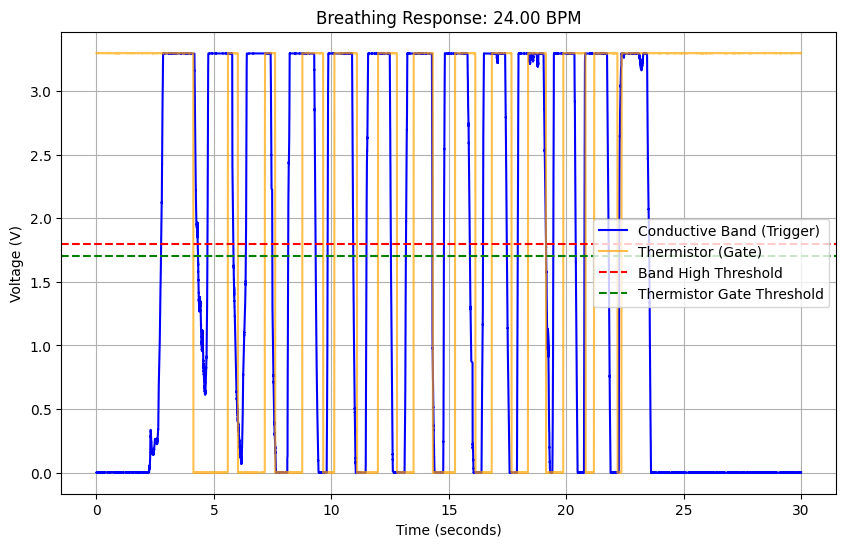

In [27]:
import struct
import time
import serial
import matplotlib.pyplot as plt

# --- Configuration ---
PORT            = "COM10"
BAUDRATE        = 115200
PACKET_FORMAT   = "<BHH" 
PAYLOAD_SIZE    = struct.calcsize(PACKET_FORMAT) - 1
START_DELIMITER = 0xAA

# --- Detection Settings ---
BAND_HIGH = 1.8 
BAND_LOW  = 0.6
THERM_HIGH = 1.7 
COOLDOWN = 0.1 

# --- Trial Settings ---
TRIAL_DURATION = 30  # Set duration in seconds (e.g., 30 for exercise)

# State and Data Tracking
breath_count = 0
band_armed   = False
last_breath_time = 0
voltages_band = []
voltages_therm = []
timestamps = []

print(f"Connecting to {PORT}...")

with serial.Serial(PORT, BAUDRATE, timeout=1) as ser:
    ser.reset_input_buffer()
    print(f"System Active. Recording for {TRIAL_DURATION} seconds...\n")
    
    start_time = time.time()
    
    while (time.time() - start_time) < TRIAL_DURATION:
        byte = ser.read(1)
        if not byte or byte[0] != START_DELIMITER:
            continue

        payload = ser.read(PAYLOAD_SIZE)
        if len(payload) != PAYLOAD_SIZE:
            continue

        # Unpack: Note - ensure order matches your STM32 (therm then band or vice versa)
        _, adc_therm, adc_band = struct.unpack(PACKET_FORMAT, byte + payload)
        
        v_band = (adc_band / 4095.0) * 3.3
        v_therm = (adc_therm / 4095.0) * 3.3
        
        # Save data for plotting
        current_relative_time = time.time() - start_time
        timestamps.append(current_relative_time)
        voltages_band.append(v_band)
        voltages_therm.append(v_therm)

        # --- Gated Fusion Logic ---
        is_breathing_physically = v_therm < THERM_HIGH

        if v_band < BAND_LOW:
            band_armed = True

        current_time = time.time()
        if v_band > BAND_HIGH and band_armed and is_breathing_physically:
            if (current_time - last_breath_time) > COOLDOWN:
                breath_count += 1
                last_breath_time = current_time
                band_armed = False 
                print(f"\n[VALIDATED BREATH] Count: {breath_count}")

        status = "ON " if is_breathing_physically else "OFF"
        print(f"Time: {current_relative_time:.1f}s | Gate: {status} | Band: {v_band:.2f}V | Total: {breath_count}", end="\r")

# --- Final Estimation (Requirement 8) ---
actual_duration = timestamps[-1] if timestamps else TRIAL_DURATION
breath_rate_bpm = (breath_count / actual_duration) * 60

print(f"\n\n--- Trial Complete ---")
print(f"Total Breaths: {breath_count}")
print(f"Measured Duration: {actual_duration:.2f} seconds")
print(f"Estimated Breath Rate: {breath_rate_bpm:.2f} BPM")

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(timestamps, voltages_band, label='Conductive Band (Trigger)', color='blue')
plt.plot(timestamps, voltages_therm, label='Thermistor (Gate)', color='orange', alpha=0.7)
plt.axhline(y=BAND_HIGH, color='r', linestyle='--', label='Band High Threshold')
plt.axhline(y=THERM_HIGH, color='g', linestyle='--', label='Thermistor Gate Threshold')
plt.title(f"Breathing Response: {breath_rate_bpm:.2f} BPM")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()